# Tutorial: ChemBERTa: Large-Scale Self-Supervised Pretraining for Molecular Property Prediction using a Smiles Tokenization Strategy

![alt text](https://huggingface.co/front/assets/huggingface_mask.svg)

By Seyone Chithrananda ([Twitter](https://twitter.com/SeyoneC))

Deep learning for chemistry and materials science remains a novel field with lots of potiential. However, the popularity of transfer learning based methods in areas such as natural language processing (NLP) and computer vision have not yet been effectively developed in computational chemistry + machine learning. Using HuggingFace's suite of models and the ByteLevel tokenizer, we are able to train a large-transformer model, RoBERTa, on a large corpus of 10,000,000 SMILES strings from a commonly known benchmark chemistry dataset, PubChem.

Training RoBERTa over 10 epochs, the model achieves a pretty good loss of 0.198, and may likely continue to converge if trained for a larger number of epochs. The model can predict masked/corrupted tokens within a SMILES sequence/molecule, allowing for variants of a molecule within discoverable chemical space to be predicted.

By applying the representations of functional groups and atoms learned by the model, we can try to tackle problems of toxicity, solubility, drug-likeness, and synthesis accessibility on smaller datasets using the learned representations as features for graph convolution and attention models on the graph structure of molecules, as well as fine-tuning of BERT. Finally, we propose the use of attention visualization as a helpful tool for chemistry practitioners and students to quickly identify important substructures in various chemical properties.

Additionally, visualization of the attention mechanism have been seen through previous research as incredibly valuable towards chemical reaction classification. The applications of open-sourcing large-scale transformer models such as RoBERTa with HuggingFace may allow for the acceleration of these individual research directions.

A link to a repository which includes the training, uploading and evaluation notebook (with sample predictions on compounds such as Remdesivir) can be found [here](https://github.com/seyonechithrananda/bert-loves-chemistry). All of the notebooks can be copied into a new Colab runtime for easy execution. This repository will be updated with new features, such as attention visualization, easier benchmarking infrastructure, and more. The work behind this tutorial has been published on [Arxiv](https://arxiv.org/abs/2010.09885), and was accepted for a **poster presentation at NeurIPS 2020's ML for Molecules Workshop**.

For the sake of this tutorial, we'll be fine-tuning a pre-trained ChemBERTa on a small-scale molecule dataset, Clintox, to show the potiential and effectiveness of HuggingFace's NLP-based transfer learning applied to computational chemistry. Output for some cells are purposely cleared for readability, so do not worry if some output messages for your cells differ!

In short, there are three major components we'll be going over in this notebook.
1. Masked token inference predictions on SMILES strings
2. Attention visualizaiton of the PubChem-10M model
3. Fine-tuninhg BPE-ChemBERTa and Smiles-Tokenizer ChemBERTa model's on the CLintox toxicity dataset.

**Don't worry if you aren't familiar with some of these terms. We will explain them later in the tutorial!**

If you're looking to dive deeper, check out the poster [here](https://seyonechithrananda.com/ChemBERTa-DeepChem-e1244b82c8fb40bca8c3c882acb9baa5).

## Colab

This tutorial and the rest in this sequence are designed to be done in Google colab. If you'd like to open this notebook in colab, you can use the following link.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/deepchem/deepchem/blob/master/examples/tutorials/Transfer_Learning_With_ChemBERTa_Transformers.ipynb)

## Setup

To run DeepChem within Colab, you'll need to run the following cell of installation commands. This will take about 5 minutes to run to completion and install your environment.


In [ ]:
!apt-get update -qq
!apt-get install -y python3-rdkit

!pip install torch torchvision torchaudio
!pip install transformers
!pip install torch-geometric
!pip install deepchem --no-deps

In [ ]:
from rdkit import Chem

import deepchem as dc

print(dc.__version__)

print(Chem.MolFromSmiles("CCO"))

We want to install NVIDIA's Apex tool, for the training pipeline used by `simple-transformers` and Weights and Biases. This package enables us to use 16-bit training, mixed precision, and distributed training without any changes to our code. Generally GPUs are good at doing 32-bit(single precision) math, not at 16-bit(half) nor 64-bit(double precision). Therefore traditionally deep learning model trainings are done in 32-bit. By switching to 16-bit, we’ll be using half the memory and theoretically less computation at the expense of the available number range and precision. However, pure 16-bit training creates a lot of problems for us (imprecise weight updates, gradient underflow and overflow). **Mixed precision training, with Apex, alleviates these problems**.

We will be installing `simple-transformers`, a library which builds ontop of HuggingFace's `transformers` package specifically for fine-tuning ChemBERTa.

In [ ]:
!git clone https://github.com/NVIDIA/apex
!cd /content/apex
!pip install -v --no-cache-dir /content/apex
!pip install transformers
!pip install simpletransformers
!pip install wandb
!cd ..

In [ ]:
import sys
!test -d bertviz_repo && echo "FYI: bertviz_repo directory already exists, to pull latest version uncomment this line: !rm -r bertviz_repo"
# !rm -r bertviz_repo # Uncomment if you need a clean pull from repo
!test -d bertviz_repo || git clone https://github.com/jessevig/bertviz bertviz_repo
if not 'bertviz_repo' in sys.path:
  sys.path += ['bertviz_repo']
!pip install regex

We're going to clone an auxillary repository, bert-loves-chemistry, which will enable us to use the MolNet dataloader for ChemBERTa, which automatically generates scaffold splits on any MoleculeNet dataset!

In [ ]:
!git clone https://github.com/seyonechithrananda/bert-loves-chemistry.git

In [ ]:
!nvidia-smi

Now, to ensure our model demonstrates an understanding of chemical syntax and molecular structure, we'll be testing it on predicting a masked token/character within the SMILES molecule for benzene.

In [ ]:
# Test if NVIDIA apex training tool works
from apex import amp

# What is a tokenizer?

A tokenizer is in charge of preparing the inputs for a natural language processing model. For many scientific applications, it is possible to treat inputs as “words”/”sentences” and use NLP methods to make meaningful predictions. For example, SMILES strings or DNA sequences have grammatical structure and can be usefully modeled with NLP techniques. DeepChem provides some scientifically relevant tokenizers for use in different applications. These tokenizers are based on those from the Huggingface transformers library (which DeepChem tokenizers inherit from).

The base classes PreTrainedTokenizer and PreTrainedTokenizerFast in HuggingFace implements the common methods for encoding string inputs in model inputs and instantiating/saving python tokenizers either from a local file or directory or from a pretrained tokenizer provided by the library (downloaded from HuggingFace’s AWS S3 repository).


PreTrainedTokenizer [(transformers.PreTrainedTokenizer)](https://huggingface.co/transformers/main_classes/tokenizer.html#transformers.PreTrainedTokenizer)) thus implements the main methods for using all the tokenizers:
* Tokenizing (spliting strings in sub-word token strings), converting tokens strings to ids and back, and encoding/decoding (i.e. tokenizing + convert to integers),

* Adding new tokens to the vocabulary in a way that is independant of the underlying structure (BPE, SentencePiece…),

* Managing special tokens like mask, beginning-of-sentence, etc tokens (adding them, assigning them to attributes in the tokenizer for easy access and making sure they are not split during tokenization)


The default tokenizer used by ChemBERTa, is a Byte-Pair-Encoder (BPE). It is a hybrid between character and word-level representations, which allows for the handling of large vocabularies in natural language corpora. Motivated by the intuition that rare and unknown words can often be decomposed into multiple known subwords, BPE finds the best word segmentation by iteratively and greedily merging frequent pairs of characters.  

First, lets load the model's Byte-Pair Encoding tokenizer, and model, and setup a Huggingface pipeline for masked tokeni prediction.

In [ ]:
from transformers import AutoModelForMaskedLM, AutoTokenizer, pipeline, RobertaModel, RobertaTokenizer
from bertviz import head_view

model = AutoModelForMaskedLM.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k")
tokenizer = AutoTokenizer.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k")

fill_mask = pipeline('fill-mask', model=model, tokenizer=tokenizer)


#What is a transformer model?

Previously, we spoke about the attention mechanism in modern deep learning models. Attention is a concept that helped improve the performance of neural machine translation applications. The **Transformer** is a model that uses attention to boost the speed with which these models can be trained.

With the emergence of BERT by Google AI in 2018, transformers have quickly shot to the top of emerging deep learning methods, outperforming Neural Machine Translation models such as seq2seq and recurrent neural networks at dozens of tasks.

The biggest benefit, however, comes from how The Transformer lends itself to efficient **pre-training**. Using the same pre-training procedure used by RoBERTa, a follow-up work of BERT, which masks 15\% of the tokens, we mask 15\% of the tokens in each SMILES string and assign a maximum sequence length of 256 characters.

The model then learns to **predict masked tokens consisting of atoms and functional groups**, or specific groups of atoms within molecules which have their own characteristic properties. Through this, the model learns the relevant molecular context for transferable tasks, such as property prediction.

ChemBERTa employs a bidirectional training context to learn context-aware representations of the PubChem 10M dataset, downloadable through MoleculeNet for self-supervised pre-training ([link](https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/pubchem_10m.txt.zip)). Our variant of the BERT transformer uses 12 attention heads and 6 layers, resulting in 72 distinct attention mechanisms.


The Transformer was proposed in the paper Attention is All You Need.

Now, to ensure our the ChemBERTa model demonstrates an understanding of chemical syntax and molecular structure, we'll be testing it on predicting a masked token/character within the SMILES molecule for benzene. Using the Huggingface pipeline we initialized earlier we can fetch a list of the model's predictions by confidence score:




In [ ]:
smiles_mask = "C1=CC=CC<mask>C1"
smiles = "C1=CC=CC=C1"

masked_smi = fill_mask(smiles_mask)

for smi in masked_smi:
  print(smi)

Here, we get some interesting results. The final branch, `C1=CC=CC=C1`, is a  benzene ring. Since its a pretty common molecule, the model is easily able to predict the final double carbon bond with a score of 0.98. Let's get a list of the top 5 predictions (including the target, Remdesivir), and visualize them (with a highlighted focus on the beginning of the final benzene-like pattern). To visualize them, we'll be using the RDKit cheminoformatics package we installed earlier, specifically the `rdkit.chem.Draw` module.


In [ ]:
import torch
import rdkit
import rdkit.Chem as Chem
from rdkit.Chem import rdFMCS
from matplotlib import colors
from rdkit.Chem import Draw
from rdkit.Chem.Draw import MolToImage
from PIL import Image


def get_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    Chem.Kekulize(mol)
    return mol


def find_matches_one(mol,submol):
    #find all matching atoms for each submol in submol_list in mol.
    match_dict = {}
    mols = [mol,submol] #pairwise search
    res=rdFMCS.FindMCS(mols) #,ringMatchesRingOnly=True)
    mcsp = Chem.MolFromSmarts(res.smartsString)
    matches = mol.GetSubstructMatches(mcsp)
    return matches

#Draw the molecule
def get_image(mol,atomset):
    hcolor = colors.to_rgb('green')
    if atomset is not None:
        #highlight the atoms set while drawing the whole molecule.
        img = MolToImage(mol, size=(600, 600),fitImage=True, highlightAtoms=atomset,highlightColor=hcolor)
    else:
        img = MolToImage(mol, size=(400, 400),fitImage=True)
    return img

In [ ]:
sequence = f"C1=CC=CC={tokenizer.mask_token}1"
substructure = "CC=CC"
image_list = []

input = tokenizer.encode(sequence, return_tensors="pt")
mask_token_index = torch.where(input == tokenizer.mask_token_id)[1]

token_logits = model(input)[0]
mask_token_logits = token_logits[0, mask_token_index, :]

top_5_tokens = torch.topk(mask_token_logits, 5, dim=1).indices[0].tolist()

for token in top_5_tokens:
  smi = (sequence.replace(tokenizer.mask_token, tokenizer.decode([token])))
  print (smi)
  smi_mol = get_mol(smi)
  substructure_mol = get_mol(substructure)
  if smi_mol is None: # if the model's token prediction isn't chemically feasible
    continue
  Draw.MolToFile(smi_mol, smi+".png")
  matches = find_matches_one(smi_mol, substructure_mol)
  atomset = list(matches[0])
  img = get_image(smi_mol, atomset)
  img.format="PNG"
  image_list.append(img)

In [ ]:
from IPython.display import Image

for img in image_list:
  display(img)

As we can see above, 5 out of 5 of the model's MLM predictions are chemically valid. Overall, the model seems to understand syntax with a pretty decent degree of certainity.

However, further training on a more specific dataset (say leads for a specific target) may generate a stronger chemical transformer model. Let's now fine-tune our model on a dataset of our choice, ClinTox. You can run ChemBERTa on any MoleculeNet dataset, but for the sake of convinience, we will use ClinTox as it is small and trains quickly.

# What is attention?
Previously, recurrent models struggled with generating a fixed-length vector for large sequences, leading to deteriorating performance as the length of an input sequence increased.

Attention is, to some extent, motivated by how we pay visual attention to different regions of our vision or how we correlate words in a sentence. Human visual attention allows us to focus on a certain subregion with a higher focus while perceiving the surrounding image in with a lower focus, and then adjust the focal point.

Similarly, we can explain the relationship between words in one sentence or close context. When we see “eating”, we expect to read a food word very soon. The color term describes the food, but probably not as directly as “eating” does:


---



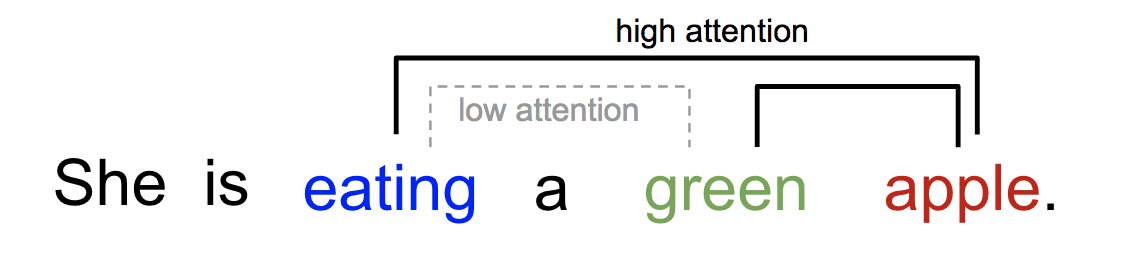


---



The attention mechanism extends on the encoder-decoder model, by taking in three values for a SMILES sequence: a value vector (V), a query vector (Q) and a key vector (K).

Each vector is similar to a type of word embedding, specifically for determining the compatibility of neighbouring tokens. From these vectors, a dot production attention is derived from the dot product of the query vector of one word, and the key vector of the other.

A scaling factor of $\frac{1}{\sqrt{d_k}}$is added to the dot product attention such that the value doesn't grow too large in respect to $d_k$, the dimension of the key. The softmax normalization function is applied to return a score between 0 to 1 for each individual token:

\begin{equation}
    \textrm{Attention}(Q, K, V) = \textrm{softmax} \left (\frac{QK^T}{\sqrt{d_k}} \right )V
\end{equation}



# Visualizing the Attention Mechanism in ChemBERTa using BertViz

[BertViz](https://github.com/jessevig/bertviz) is a tool for visualizing attention in the Transformer model, supporting all models from the transformers library (BERT, GPT-2, XLNet, RoBERTa, XLM, CTRL, etc.). It extends the Tensor2Tensor visualization tool by Llion Jones and the transformers library from HuggingFace.

Using this tool, we can easily plug in ChemBERTa from the HuggingFace model hub and visualize the attention patterns produced by one or more attention heads in a given transformer layer. This is known as the attention-head view.

Lets start by obtaining a Javascript object for d3.js and jquery to create interactive visualizations:


In [ ]:
%%javascript
require.config({
  paths: {
      d3: '//cdnjs.cloudflare.com/ajax/libs/d3/3.4.8/d3.min',
      jquery: '//ajax.googleapis.com/ajax/libs/jquery/2.0.0/jquery.min',
  }
});

In [ ]:
def call_html():
  import IPython
  display(IPython.core.display.HTML('''
        <script src="/static/components/requirejs/require.js"></script>
        <script>
          requirejs.config({
            paths: {
              base: '/static/base',
              "d3": "https://cdnjs.cloudflare.com/ajax/libs/d3/3.5.8/d3.min",
              jquery: '//ajax.googleapis.com/ajax/libs/jquery/2.0.0/jquery.min',
            },
          });
        </script>
        '''))

Now, we create an instance of ChemBERTa, tokenize a set of SMILES strings, and compute the attention for each head in the transformer. There are two available models hosted by DeepChem on HuggingFace's model hub, one being `seyonec/ChemBERTa-zinc-base-v1` which is the ChemBERTa model trained via masked lagnuage modelling (MLM) on the ZINC100k dataset, and the other being `seyonec/ChemBERTa-zinc250k-v1`, which is trained via MLM on the larger ZINC250k dataset.




In the following example, we take two SMILES molecules from the ZINC database with nearly identical chemical structure, the only difference being rooted in chiral specification (hence the additional `‘@‘` symbol). This is a feature of molecules which indicates that there exists tetrahedral centres. `‘@'` tells us whether the neighbours of a molecule appear in a counter-clockwise order, whereas `‘@@‘` indicates that the neighbours are ordered in a clockwise direction. The model should ideally refer to similar substructures in each SMILES string with a higher attention weightage.

Lets look at the first SMILES string: `CCCCC[C@@H](Br)CC`:





In [ ]:
m = Chem.MolFromSmiles('CCCCC[C@@H](Br)CC')
fig = Draw.MolToMPL(m, size=(200, 200))

And the second SMILES string, `CCCCC[C@H](Br)CC`:


In [ ]:
m = Chem.MolFromSmiles('CCCCC[C@H](Br)CC')
fig = Draw.MolToMPL(m, size=(200,200))

The visualization below shows the attention induced by a sample input SMILES. This view visualizes attention as lines connecting the tokens being updated (left) with the tokens being attended to (right), following the design of the figures above. Color intensity reflects the attention weight; weights close to one show as very dark lines, while weights close to zero appear as faint lines or are not visible at all. The user may highlight a particular SMILES character to see the attention from that token only. This visualization is called the attention-head view. It is based on the excellent Tensor2Tensor visualization tool, and are all generated by the [Bertviz](https://github.com/jessevig/bertviz) library.


In [ ]:
from transformers import RobertaModel, RobertaTokenizer
from bertviz import head_view

model_version = 'seyonec/PubChem10M_SMILES_BPE_450k'
model = RobertaModel.from_pretrained(model_version, output_attentions=True)
tokenizer = RobertaTokenizer.from_pretrained(model_version)

sentence_a = "CCCCC[C@@H](Br)CC"
sentence_b = "CCCCC[C@H](Br)CC"
inputs = tokenizer.encode_plus(sentence_a, sentence_b, return_tensors='pt', add_special_tokens=True)
input_ids = inputs['input_ids']
attention = model(input_ids)[-1]
input_id_list = input_ids[0].tolist() # Batch index 0
tokens = tokenizer.convert_ids_to_tokens(input_id_list)

call_html()

head_view(attention, tokens)

# Smiles-Tokenizer Attention by Head View
![alt text](https://media.giphy.com/media/zpfTwb3Og65ifEWymt/giphy.gif)

The visualization shows that attention is highest between words that don’t cross a boundary between the two SMILES strings; the model seems to understand that it should relate tokens to other tokens in the same molecule in order to best understand their context.

There are many other fascinating visualizations we can do, such as a neuron-by neuron analysis of attention or a model overview that visualizes all of the heads at once:

# Attention by Head View:
![alt text](https://media.giphy.com/media/cLGrM5gfbqj63k2bU2/giphy.gif)
# Model View:
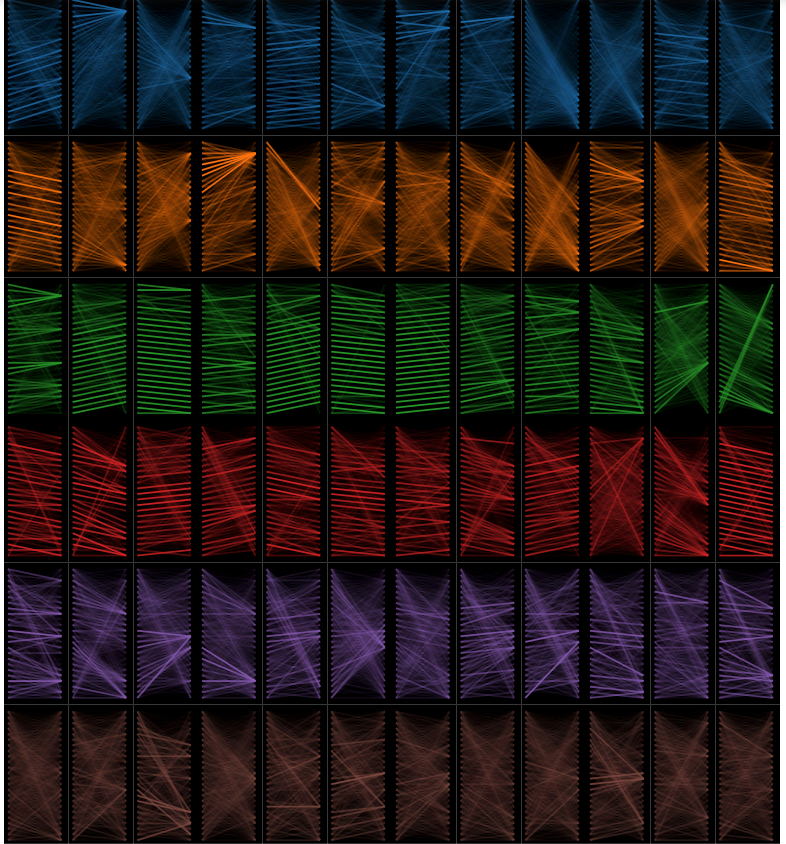

# Neuron-by-neuron view:




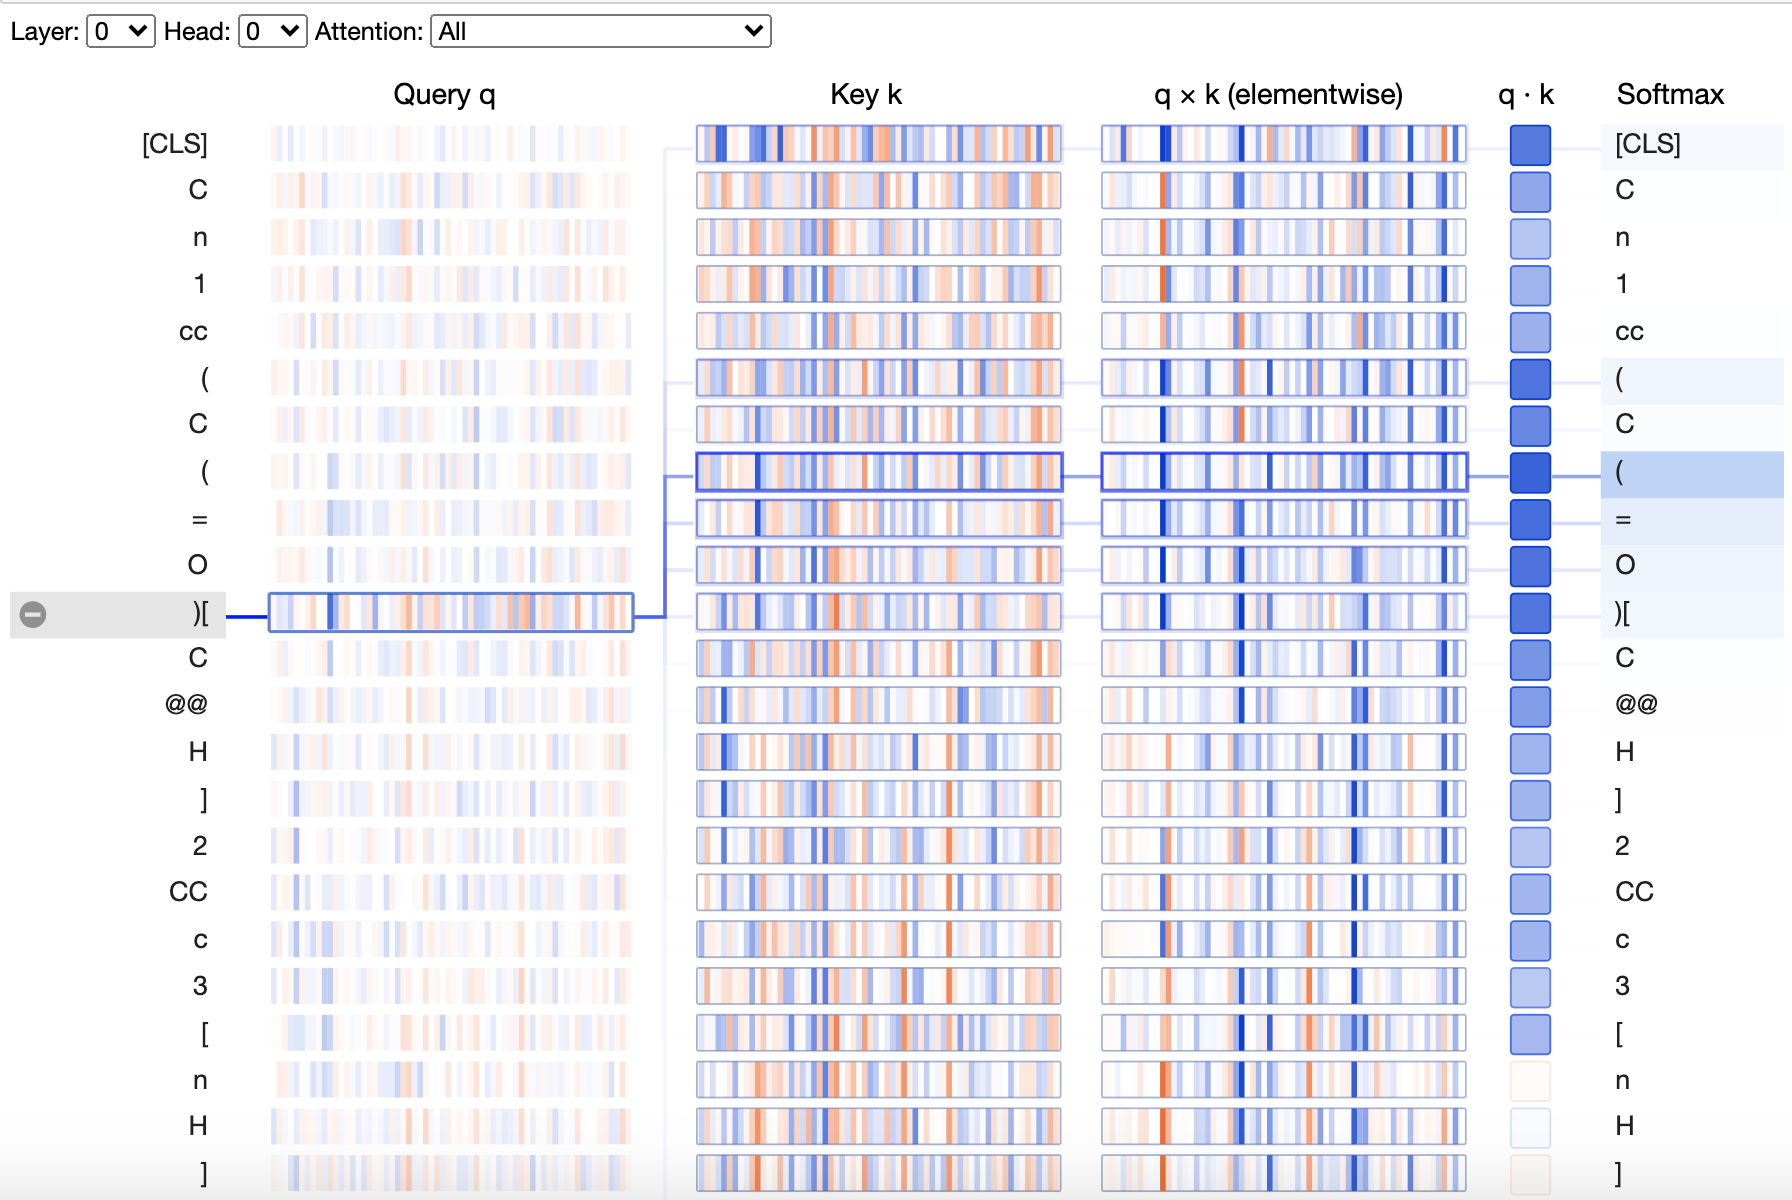

You can try out the ChemBERTa attention visualization demo's in more detail, with custom SMILES/SELFIES strings, tokenizers, and more in the public library, [here](https://github.com/seyonechithrananda/bert-loves-chemistry).

# What is Transfer Learning, and how does ChemBERTa utilize it?

Transfer learning is a research problem in machine learning that focuses on **storing knowledge gained while solving one problem and applying it to a different but related problem**.

By pre-training directly on SMILES strings, and teaching ChemBERTa to recognize masked tokens in each string, the model learns a strong molecular representation. We then can take this model, trained on a structural chemistry task, and apply it to a suite of classification tasks in the MoleculeNet suite, from Tox21 to BBBP!



# Fine-tuning ChemBERTa on a Small Mollecular Dataset

Our fine-tuning dataset, ClinTox, consists of qualitative data of drugs approved by the FDA and those that have failed clinical trials for toxicity reasons.

The ClinTox dataset consists of 1478 binary labels for toxicity, using the SMILES representations for identifying molecules. The computational models produced from the dataset could become decision-making tools for government agencies in determining which drugs are of the greatest potential concern to human health. Additionally, these models can act as drug screening tools in the drug discovery pipelines for toxicity.

Let's start by importing the MolNet dataloder from `bert-loves-chemistry`, before importing apex and transformers, the tool which will allow us to import the ChemBERTA language model (LM) trained on PubChem-10M.

In [ ]:
%cd /content/bert-loves-chemistry

In [ ]:
!pwd

In [ ]:
import os

import numpy as np
import pandas as pd

from typing import List

# import molnet loaders from deepchem
from deepchem.molnet import load_bbbp, load_clearance, load_clintox, load_delaney, load_hiv, load_qm7, load_tox21
from rdkit import Chem


# import MolNet dataloder from bert-loves-chemistry fork
from chemberta.utils.molnet_dataloader import load_molnet_dataset, write_molnet_dataset_for_chemprop


#But why use custom Smiles-Tokenizer's over BPE?

In this tutorial, we will be comparing the BPE tokenization algorithm with a **custom SmilesTokenizer** based on a regex pattern, which we have released as part of DeepChem. To compare tokenizers, we pretrained an identical model tokenized using this novel tokenizer, on the PubChem-1M set. The pretrained model was evaluated on the BBBP and Tox21 in the paper. We found that the SmilesTokenizer narrowly outperformed the BPE algorithm by ∆PRC-AUC = $+0.021$.

Though this result suggests that a more semantically relevant tokenization may provide performance benefits, further benchmarking on additional datasets is needed to validate this finding. **In this tutorial, we aim to do so, by testing this alternate model on the ClinTox dataset.**

Let's fetch the Smiles Tokenizer's character per line vocabulary file, which can bve loaded from the DeepChem S3 data bucket:

In [ ]:
!wget https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/vocab.txt

Lets use the MolNet dataloader to generate scaffold splits from the ClinTox dataset.

In [ ]:
tasks, (train_df, valid_df, test_df), transformers = load_molnet_dataset("clintox", tasks_wanted=None)


If you're only running the toxicity prediction portion of this tutorial, make sure you install transformers here. If you've ran all the cells before, you can ignore this install as we've already done `pip install transformers` before.

In [ ]:
!pip install transformers

In [ ]:
train_df

In [ ]:
valid_df

In [ ]:
test_df

From here, lets set up a logger to record if any issues occur, and notify us if there are any problems with the arguments we've set for the model.

In [ ]:
from simpletransformers.classification import ClassificationModel
import logging
logging.basicConfig(level=logging.INFO)
transformers_logger = logging.getLogger("transformers")
transformers_logger.setLevel(logging.WARNING)


Now, using `simple-transformer`, let's load the pre-trained model from HuggingFace's useful model-hub. We'll set the number of epochs to 10 in the arguments, but you can train for longer, and pass early-stopping as an argument to prevent overfitting. Also make sure that `auto_weights` is set to True to do automatic weight balancing, as we are dealing with imbalanced toxicity datasets.

In [ ]:
from simpletransformers.classification import ClassificationModel, ClassificationArgs

model = ClassificationModel('roberta', 'seyonec/PubChem10M_SMILES_BPE_396_250', args={'evaluate_each_epoch': True, 'evaluate_during_training_verbose': True, 'no_save': True, 'num_train_epochs': 10, 'auto_weights': True}) # You can set class weights by using the optional weight argument


In [ ]:
print(model.tokenizer)

In [ ]:
# check if our train and evaluation dataframes are setup properly. There should only be two columns for the SMILES string and its corresponding label.
print("Train Dataset: {}".format(train_df.shape))
print("Eval Dataset: {}".format(valid_df.shape))
print("TEST Dataset: {}".format(test_df.shape))

Now that we've set everything up, lets get to the fun part: training the model! We use Weights and Biases, which is optional (simply remove `wandb_project` from the list of `args`). Its a really useful tool for monitering the model's training results (such as accuracy, learning rate and loss), alongside custom visualizations of attention and gradients.

When you run this cell, Weights and Biases will ask for an account, which you can setup through a Github account, giving you an authorization API key which you can paste into the output of the cell. Again, this is completely optional and it can be removed from the list of arguments.

In [ ]:
!wandb login

Finally, the moment we've been waiting for! Let's train the model on the train scaffold set of ClinTox, and monitor our runs using W&B. We will evaluate the performance of our model each epoch using the validation set.

In [ ]:
# Create directory to store model weights (change path accordingly to where you want!)
!mkdir BPE_PubChem_10M_ClinTox_run

# Train the model
model.train_model(train_df, eval_df=valid_df, output_dir='/content/BPE_PubChem_10M_ClinTox_run', args={'wandb_project': 'project-name'})


Let's install scikit-learn now, to evaluate the model we've trained. We will be using the accuracy and PRC-AUC metrics (average precision score).

In [ ]:
import sklearn

# accuracy
result, model_outputs, wrong_predictions = model.eval_model(test_df, acc=sklearn.metrics.accuracy_score)

# ROC-PRC
result, model_outputs, wrong_predictions = model.eval_model(test_df, acc=sklearn.metrics.average_precision_score)



The model performs pretty well, averaging above 97% ROC-PRC after training on only ~1400 data samples and 150 positive leads in a couple of minutes! We can clearly see the predictive power of transfer learning, and approaches like these are becoming increasing popular in the pharmaceutical industry where larger datasets are scarce. By training on more epochs and tasks, we can probably boost the accuracy as well!

Lets evaluate the model on one last string from ClinTox's test set for toxicity. The model should predict 1, meaning the drug failed clinical trials for toxicity reasons and wasn't approved by the FDA.

In [ ]:
# Lets input a molecule with a toxicity value of 1
predictions, raw_outputs = model.predict(['C1=C(C(=O)NC(=O)N1)F'])


In [ ]:
print(predictions)
print(raw_outputs)

The model predicts the sample correctly! Some future tasks may include using the same model on multiple tasks (Tox21 provides multiple tasks relating to different biochemical pathways for toxicity, as an example), through multi-task classification, as well as training on a larger dataset such as HIV, one of the other harder tasks in molecular machine learning. This will be expanded on in future work!

# Benchmarking Smiles-Tokenizer ChemBERTa models on ClinTox

Now lets compare how this model performs to a similar variant of ChemBERTa, that utilizes a different tokenizer, the [SmilesTokenizer](https://deepchem.readthedocs.io/en/latest/api_reference/tokenizers.html) which is built-in to DeepChem! Let see if using a tokenizer which splits SMILES sequences into syntatically relevant chemical tokens performs differently, especially on molecular property prediction.

First off, lets initialize this variant model:

In [ ]:
from simpletransformers.classification import ClassificationModel, ClassificationArgs

model = ClassificationModel('roberta', 'seyonec/SMILES_tokenized_PubChem_shard00_160k', args={'evaluate_each_epoch': True, 'evaluate_during_training_verbose': True, 'no_save': True, 'num_train_epochs': 15, 'auto_weights': True}) # You can set class weights by using the optional weight argument


In [ ]:
print(model.tokenizer)

In [ ]:
# check if our train and evaluation dataframes are setup properly. There should only be two columns for the SMILES string and its corresponding label.
print("Train Dataset: {}".format(train_df.shape))
print("Eval Dataset: {}".format(valid_df.shape))
print("TEST Dataset: {}".format(test_df.shape))

Now that we've set everything up, lets get to the fun part: training the model! We use Weights and Biases, which is optional (simply remove `wandb_project` from the list of `args`). Its a really useful tool for monitering the model's training results (such as accuracy, learning rate and loss), alongside custom visualizations of attention and gradients.

When you run this cell, Weights and Biases will ask for an account, which you can setup through a Github account, giving you an authorization API key which you can paste into the output of the cell. Again, this is completely optional and it can be removed from the list of arguments.

In [ ]:
!wandb login

In [ ]:
# Create directory to store model weights (change path accordingly to where you want!)
!mkdir SmilesTokenizer_PubChem_10M_ClinTox_run

# Train the model
model.train_model(train_df, eval_df=valid_df, output_dir='/content/SmilesTokenizer_PubChem_10M_ClinTox_run', args={'wandb_project': 'project-name'})


Let's install scikit-learn now, to evaluate the model we've trained. We will be using the accuracy and PRC-AUC metrics (average precision score).

In [ ]:
import sklearn

# accuracy
result, model_outputs, wrong_predictions = model.eval_model(test_df, acc=sklearn.metrics.accuracy_score)

# ROC-PRC
result, model_outputs, wrong_predictions = model.eval_model(test_df, acc=sklearn.metrics.average_precision_score)



The model performs incredibly well, averaging above 96% PRC-AUC after training on only ~1400 data samples and 150 positive leads in a couple of minutes! This model was also trained on 1/10th the amount of pre-training data as the PubChem-10M BPE model we used previously, but it still showcases robust performance. We can clearly see the predictive power of transfer learning, and approaches like these are becoming increasing popular in the pharmaceutical industry where larger datasets are scarce. By training on more epochs and tasks, we can probably boost the accuracy as well!

Lets evaluate the model on one last string from ClinTox's test set for toxicity. The model should predict 1, meaning the drug failed clinical trials for toxicity reasons and wasn't approved by the FDA.

In [ ]:
# Lets input a molecule with a toxicity value of 1
predictions, raw_outputs = model.predict(['C1=C(C(=O)NC(=O)N1)F'])


In [ ]:
print(predictions)
print(raw_outputs)

The model predicts the sample correctly! Some future tasks may include using the same model on multiple tasks (Tox21 provides multiple tasks relating to different biochemical pathways for toxicity, as an example), through multi-task classification, as well as training on a larger dataset such as HIV, one of the other harder tasks in molecular machine learning. This will be expanded on in future work!

#Congratulations! Time to join the Community!
Congratulations on completing this tutorial notebook! If you enjoyed working through the tutorial, and want to continue working with DeepChem, we encourage you to finish the rest of the tutorials in this series. You can also help the DeepChem community in the following ways:

# **Star DeepChem on [Github](https://github.com/deepchem/deepchem)**
This helps build awareness of the DeepChem project and the tools for open source drug discovery that we're trying to build.

# **Join the DeepChem Gitter**
The DeepChem [Gitter](https://gitter.im/deepchem/Lobby) hosts a number of scientists, developers, and enthusiasts interested in deep learning for the life sciences. Join the conversation!
